# Parte 1: Análisis Exploratorio de Datos (EDA)

El objetivo de este notebook es conectarse a **Snowflake**, extraer un subset manejable mediante *pushdown computation* desde la vista `analytics.train_set`, y entender la distribución de los datos antes de modelar.

## Objetivos
1. Validar la conexión a Snowflake usando variables de entorno.
2. Entender el comportamiento del *Target* (`total_amount`).
3. Investigar la correlación entre variables independientes y descubrir posibles casos de *Data Leakage*.
4. Analizar la cardinalidad y distribución estadística (boxplots, histogramas).

> ⚠️ **Regla de oro**: En ningún momento cargamos los ~20 GB completos. Usamos `SAMPLE` de Snowflake para traer una muestra representativa.

---
## 0. Configuración e Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import sys
import os

# Agregar raíz del proyecto al path para importar src/
sys.path.insert(0, os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv('../.env')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


---
## 1. Conexión a Snowflake y Extracción de Muestra

Usamos la función `fetch_sample` de `src/data/ingestion.py`. El parámetro `sample_prob` indica qué porcentaje de filas se extrae con `TABLESAMPLE` de Snowflake (corre del lado del servidor, sin descargar los 20 GB).

In [10]:
from src.data.ingestion import fetch_sample

# Extraemos ~1% del train_set para el EDA (aprox. 1-3 millones de filas)
# Ajusta sample_prob si tu máquina tiene más o menos RAM
SAMPLE_PROB = 1.0  # 1% del dataset de entrenamiento

query = "SELECT * FROM ANALYTICS.TRAIN_SET"

print(f'Extrayendo muestra ({SAMPLE_PROB}%) de ANALYTICS.TRAIN_SET...')
df = fetch_sample(query, sample_prob=SAMPLE_PROB)

print(f'✅ Muestra cargada: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Extrayendo muestra (1.0%) de ANALYTICS.TRAIN_SET...
✅ Muestra cargada: 7,788,515 filas × 33 columnas


,pickup_datetime,dropoff_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,...,do_zone,do_borough,month,year,source_service,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week
0,2015-07-05 00:50:49,2015-07-05 01:13:23,148,41,"Curb Mobility, LLC",1.0,Standard rate,Flex Fare trip,6.0,6.94,...,Central Harlem,Manhattan,7,2015,yellow,2015-07-05,0,2015-07-05,1,0
1,2015-07-30 13:05:16,2015-07-30 13:52:40,161,132,"Creative Mobile Technologies, LLC",2.0,JFK,Cash,1.0,17.60,...,JFK Airport,Queens,7,2015,yellow,2015-07-30,13,2015-07-30,13,4
2,2015-07-30 13:30:16,2015-07-30 13:52:45,161,186,"Creative Mobile Technologies, LLC",1.0,Standard rate,Flex Fare trip,1.0,1.40,...,Penn Station/Madison Sq West,Manhattan,7,2015,yellow,2015-07-30,13,2015-07-30,13,4


### 1.1 Vista general del esquema

In [11]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes.to_string())
print(f'\nMemoria usada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

=== TIPOS DE DATOS ===
pickup_datetime          datetime64[ns]
dropoff_datetime         datetime64[ns]
pu_location_id                   object
do_location_id                   object
vendor_name                      object
rate_code_id                    float64
rate_code_desc                   object
payment_type_desc                object
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
run_id                           object
ingested_at_utc          datetime64[ns]
pu_zone                          object
pu_borough                       object
do_zone                          object
do_borough       

In [12]:
print('=== VALORES NULOS (%) ===')
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string())
if null_pct.max() == 0:
    print('Sin valores nulos en la muestra.')

=== VALORES NULOS (%) ===
airport_fee             95.630066
congestion_surcharge    72.191631
passenger_count          0.942067
rate_code_id             0.942067


In [16]:
print('=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===')
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===


,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
pickup_datetime,7788515,2018-01-29 09:21:41.146726656,2015-01-01 00:00:17,2015-01-17 16:32:49.280000,2015-03-23 00:43:35.700000,2016-03-10 18:05:41.500000,2017-08-07 12:38:45,2019-05-07 20:22:20,2023-01-03 19:14:57.100000,2023-10-23 20:14:33.400000,2023-12-31 23:58:35,NaN
dropoff_datetime,7788515,2018-01-29 09:38:40.599446784,2015-01-01 00:04:02,2015-01-17 16:45:28.680000,2015-03-23 00:56:35.700000,2016-03-10 18:24:57,2017-08-07 12:53:16,2019-05-07 20:34:03.500000,2023-01-03 19:33:33.800000,2023-10-23 20:30:09.460000,2024-01-01 00:18:09,NaN
rate_code_id,7715142.0,1.102229,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,99.0,2.24066
passenger_count,7715142.0,1.571804,0.0,1.0,1.0,1.0,1.0,2.0,5.0,6.0,9.0,1.220629
trip_distance,7788515.0,3.967196,-29.96,0.03,0.5,1.0,1.7,3.2,10.93,19.0,3005093.2,1112.408113
fare_amount,7788515.0,13.603413,-800.0,3.0,4.5,6.5,9.5,15.43,38.0,55.0,410266.86,201.181054
extra,7788515.0,0.564343,-29.6,0.0,0.0,0.0,0.5,0.5,2.5,3.5,14000.0,5.097065
mta_tax,7788515.0,0.494231,-0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,31.4,0.063799
tip_amount,7788515.0,1.950259,-76.9,0.0,0.0,0.0,1.46,2.66,6.66,12.37,1894.65,2.891772
tolls_amount,7788515.0,0.342218,-50.0,0.0,0.0,0.0,0.0,0.0,5.54,6.55,7999.92,3.382301


**📝 Conclusión 1:** 
Los resultados revelan que:
- Existen valores atípicos tanto negativos como positivos excesivamente elevados en los extremos de los quartiles. --> Son valores imposibles que deben ser eliminados.
- congestion_surcharge y airport_fee presentan cantidades masivas de nulos.
  - airport_fee se podría tratar como una variable categórica. No obstante, se aplica exclusivamente a los viajes que empiezan en LaGuardia y John F. Kennedy Airports, por lo que la información ya se encuentra contenida en pu_location --> Se eliminará en consecuencia.
  - La información de congestion_surcharge incurre en data leakage (no se puede saber previo al viaje si un taxi pasará por la "congestion zone" necesariamente). --> Se eliminará.
- passenger_count y rate_code_id presentan cantidades moderadas de nulos --> Al ser una cantidad baja pueden ser eliminados
- Existen múltiples variables categóricas con cantidad moderada de categorias - Es necesario aplicar One hot Encoding para modelos que no soportan variables categóricas nativamente.
- La magnitud de las variables en general es parecido --> poco probable que sea necesario escalar

---
## 2. Análisis Univariado del Target (`total_amount`)

Entender la variable que queremos predecir es el primer paso. Buscamos: distribución, asimetría (skewness), valores imposibles (negativos, cero) y la presencia de outliers extremos.

In [13]:
target = 'total_amount'

print(f'=== ESTADÍSTICAS DEL TARGET: {target} ===')
print(f'  Media:    ${df[target].mean():.2f}')
print(f'  Mediana:  ${df[target].median():.2f}')
print(f'  Std:      ${df[target].std():.2f}')
print(f'  Skewness: {df[target].skew():.3f}')
print(f'  Kurtosis: {df[target].kurtosis():.3f}')
print(f'  Min:      ${df[target].min():.2f}')
print(f'  Max:      ${df[target].max():.2f}')
print(f'  Negativos o cero: {(df[target] <= 0).sum():,} ({(df[target] <= 0).mean()*100:.2f}%)')

=== ESTADÍSTICAS DEL TARGET: total_amount ===
  Media:    $17.73
  Mediana:  $12.96
  Std:      $201.64
  Skewness: 1518.196
  Kurtosis: 2614832.489
  Min:      $-800.30
  Max:      $410267.66
  Negativos o cero: 16,352 (0.21%)


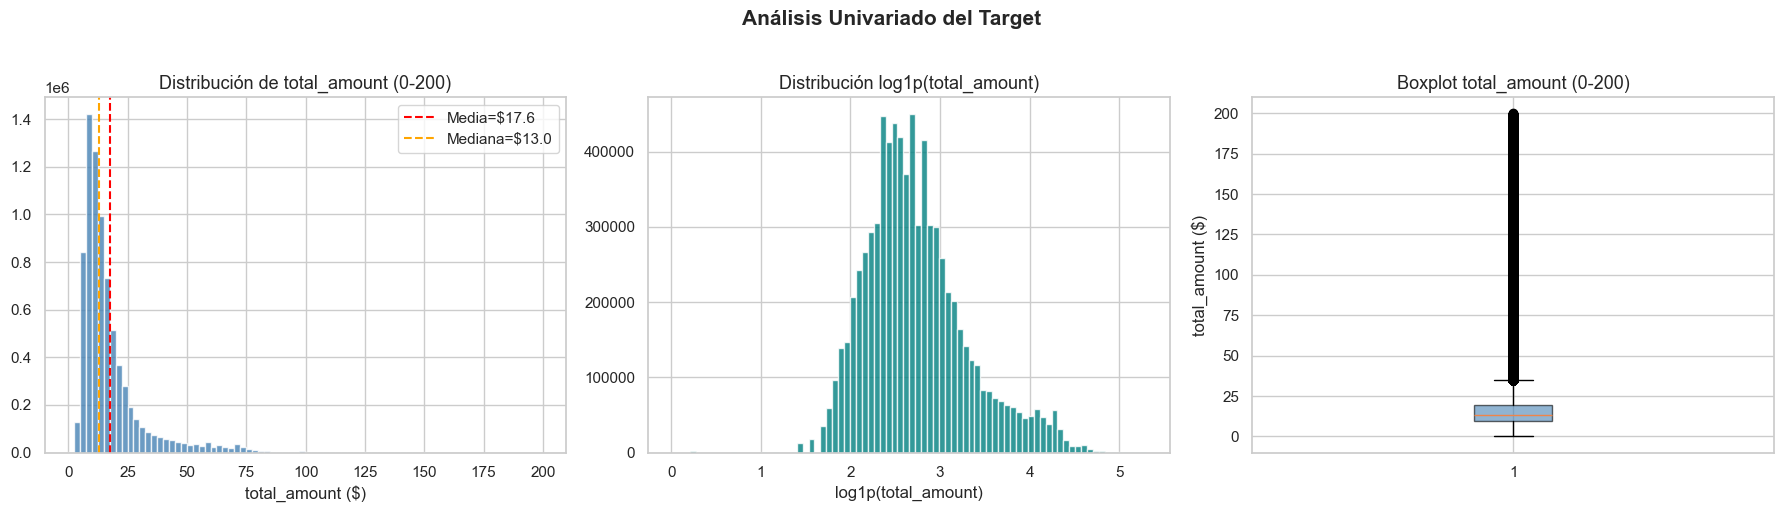

Gráfica guardada en data/interim/


In [33]:
# Filtrar rango razonable para visualizar (excluimos extremos para la gráfica)
df_plot = df[(df[target] > 0) & (df[target] < 200)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma original
axes[0].hist(df_plot[target], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_plot[target].mean(), color='red', linestyle='--', label=f'Media=${df_plot[target].mean():.1f}')
axes[0].axvline(df_plot[target].median(), color='orange', linestyle='--', label=f'Mediana=${df_plot[target].median():.1f}')
axes[0].set_title('Distribución de total_amount (0-200)', fontsize=13)
axes[0].set_xlabel('total_amount ($)')
axes[0].legend()

# Log-transformado
log_target = np.log1p(df_plot[target])
axes[1].hist(log_target, bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución log1p(total_amount)', fontsize=13)
axes[1].set_xlabel('log1p(total_amount)')

# Boxplot
axes[2].boxplot(df_plot[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Boxplot total_amount (0-200)', fontsize=13)
axes[2].set_ylabel('total_amount ($)')

plt.suptitle('Análisis Univariado del Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/interim/01_target_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfica guardada en data/interim/')

In [34]:
# Análisis de outliers por IQR
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df[target] < lower_fence) | (df[target] > upper_fence)]
print(f'Rango IQR válido: [{lower_fence:.2f}, {upper_fence:.2f}]')
print(f'Outliers por IQR: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')
print(f'\nUmbral de negocio sugerido: $2.50 (mínimo tarifa NYC) a $500')

Rango IQR válido: [-6.09, 34.95]
Outliers por IQR: 715,997 (9.19%)

Umbral de negocio sugerido: $2.50 (mínimo tarifa NYC) a $500


**📝 Conclusión 2:** El target `total_amount` presenta **asimetría positiva (right-skewed)** — hay muchos viajes baratos y una cola larga de viajes costosos. 
- Valores negativos o cero son **errores de registro** (cancelaciones, disputas) → se filtran.
- La transformación `log1p` normaliza la distribución, útil para algunos modelos lineales.
- Asmietría positiva extrema. Es necesario eliminar outliers.
- Los boosting trees (XGBoost, LightGBM, CatBoost) manejan la asimetría nativamente sin necesitar la transformación.
- Se usará un umbral de negocio: `total_amount > 2.50` y `total_amount < 500`.

---
## 3. Análisis Bivariado: Features vs Target

### 3.1 Correlación numérica con el target

In [35]:
# Columnas numéricas disponibles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Columnas numéricas ({len(numeric_cols)}): {numeric_cols}')

Columnas numéricas (17): ['rate_code_id', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'month', 'year', 'pickup_hour', 'dropoff_hour', 'day_of_week']


In [36]:
# Matriz de correlación de Pearson
corr_matrix = df[numeric_cols].corr()

# Mostrar correlación con el target ordenada
target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
print('=== CORRELACIÓN CON total_amount (Pearson) ===')
print(target_corr.to_string())

=== CORRELACIÓN CON total_amount (Pearson) ===
fare_amount              0.998558
airport_fee              0.610834
tip_amount               0.050286
tolls_amount             0.037102
extra                    0.027283
improvement_surcharge    0.013633
year                     0.012079
rate_code_id             0.007249
month                    0.002879
dropoff_hour             0.001089
pickup_hour              0.000892
trip_distance            0.000237
passenger_count         -0.000149
day_of_week             -0.000908
mta_tax                 -0.008531
congestion_surcharge    -0.008929


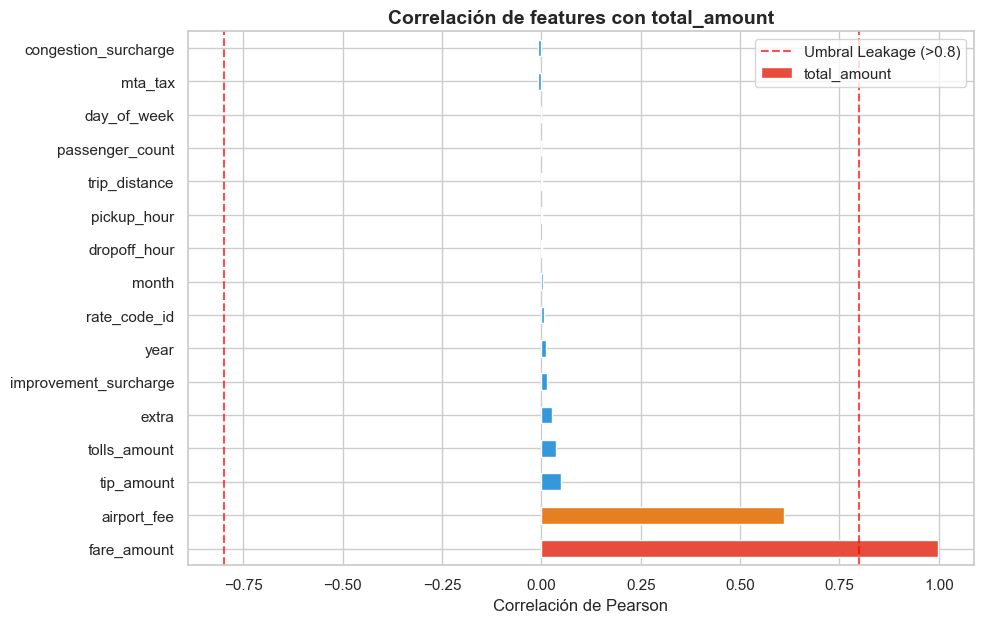

In [37]:
fig, ax = plt.subplots(figsize=(10, max(6, len(target_corr) * 0.4)))
colors = ['#e74c3c' if v > 0.8 else '#e67e22' if v > 0.5 else '#3498db' 
          for v in target_corr.abs()]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.8, color='red', linestyle='--', alpha=0.7, label='Umbral Leakage (>0.8)')
ax.axvline(-0.8, color='red', linestyle='--', alpha=0.7)
ax.set_title('Correlación de features con total_amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.legend()
plt.tight_layout()
plt.savefig('../data/interim/01_correlations.png', bbox_inches='tight', dpi=120)
plt.show()

**Observación**: Se puede contemplar que las variables con mayor correlación de pearson presentan en su mayoría data leakage. Su poder predictivo consecuentemente no puede ser utilizado.  El resto de variables seguras no presentan una correlación significativa, por lo que se espera 

### 3.2 Identificación de Data Leakage

**Data Leakage** ocurre cuando incluimos variables que solo se conocen *después* de que el viaje finaliza. En un modelo de predicción de precio, el modelo debe funcionar con información disponible **al inicio del viaje**.

In [ ]:
# Columnas que constituyen Data Leakage: son componentes del target
# o se conocen solo al FINALIZAR el viaje

LEAKAGE_COLUMNS = [
    # Componentes directos del total_amount (leakage matemático)
    'fare_amount',          # total_amount = fare_amount + extras
    'extra',                # recargos conocidos al cierre
    'mta_tax',              # tax calculado al cierre
    'tip_amount',           # propina: se da al finalizar
    'tolls_amount',         # peajes: se saben al terminar la ruta
    'congestion_surcharge', # calculado al finalizar
    'airport_fee',          # aplica solo en destinos específicos
    'tip_pct',              # derivada de tip_amount/fare_amount
    
    # Información conocida al finalizar el viaje
    'dropoff_datetime',     # solo se sabe cuando termina el viaje
    'dropoff_date',
    'dropoff_hour',
    'trip_duration_min',    # se calcula con dropoff_datetime
    'avg_speed_mph',        # requiere trip_duration_min
    'trip_distance',

    # IDs internos de trazabilidad (no predictivos)
    'run_id',
    'ingested_at_utc',
]

# Verificar cuáles existen en el dataframe
leakage_present = [c for c in LEAKAGE_COLUMNS if c in df.columns]
print(f'Columnas de leakage presentes en el dataset: {len(leakage_present)}')
for col in leakage_present:
    corr_val = df[[col, target]].corr().iloc[0, 1] if col in numeric_cols else 'N/A (categórica)'
    print(f'  ✗ {col:<30} corr={corr_val if isinstance(corr_val, str) else f"{corr_val:.3f}"}')

Columnas de leakage presentes en el dataset: 14
  ✗ fare_amount                    corr=0.999
  ✗ extra                          corr=0.027
  ✗ mta_tax                        corr=-0.009
  ✗ tip_amount                     corr=0.050
  ✗ tolls_amount                   corr=0.037
  ✗ improvement_surcharge          corr=0.014
  ✗ congestion_surcharge           corr=-0.009
  ✗ airport_fee                    corr=0.611
  ✗ dropoff_datetime               corr=N/A (categórica)
  ✗ dropoff_date                   corr=N/A (categórica)
  ✗ dropoff_hour                   corr=0.001
  ✗ trip_distance                  corr=0.000
  ✗ run_id                         corr=N/A (categórica)
  ✗ ingested_at_utc                corr=N/A (categórica)


In [ ]:
# Columnas SEGURAS (disponibles al inicio del viaje)
SAFE_COLUMNS = [
    # Características del viaje al inicio
    'passenger_count',
    'rate_code_id',
    'rate_code_desc',
    'payment_type_desc',
    'vendor_name',
    
    # Temporales del pickup
    'pickup_datetime',
    'pickup_date',
    'pickup_hour',
    'day_of_week',
    'month',
    'year',
    
    # Geográficas del origen/destino
    'pu_location_id',
    'do_location_id',
    'pu_zone',
    'pu_borough',
    'do_zone',
    'do_borough',
    
    # Metadatos de servicio
    'source_service',
    'improvement_surcharge', # cargo fijo al cierre
]

safe_present = [c for c in SAFE_COLUMNS if c in df.columns]
print(f'Columnas seguras para modelado: {len(safe_present)}')
print(safe_present)

Columnas seguras para modelado: 18
['passenger_count', 'rate_code_id', 'rate_code_desc', 'payment_type_desc', 'vendor_name', 'pickup_datetime', 'pickup_date', 'pickup_hour', 'day_of_week', 'month', 'year', 'pu_location_id', 'do_location_id', 'pu_zone', 'pu_borough', 'do_zone', 'do_borough', 'source_service']


### 3.3 Análisis temporal: Total por hora del día

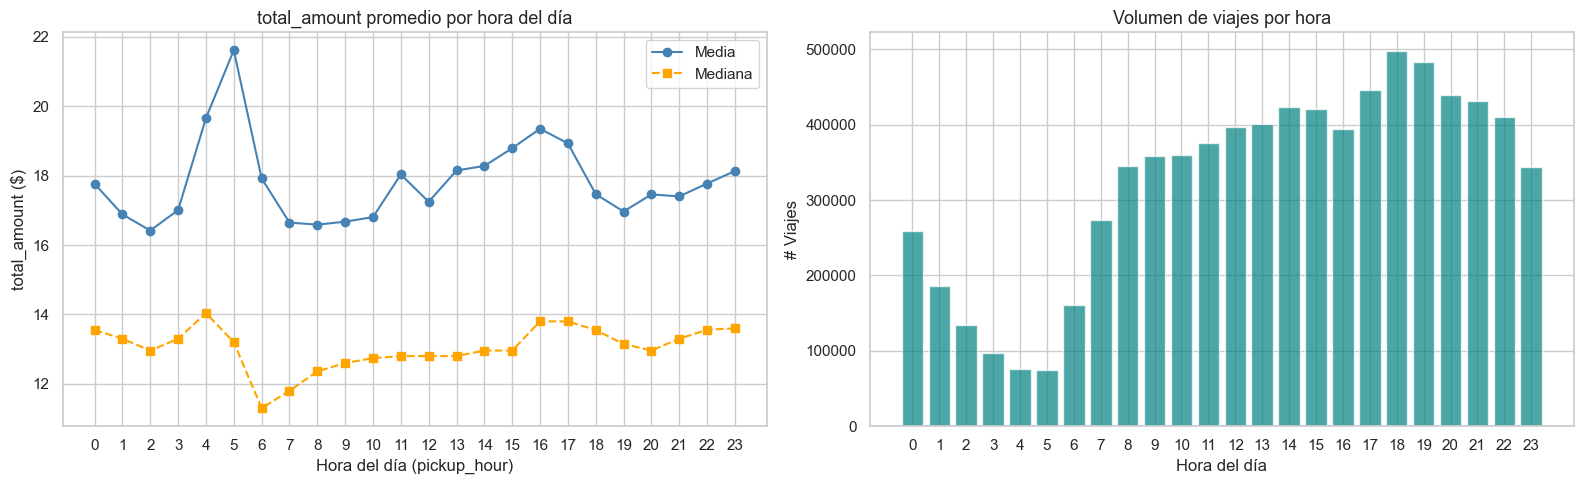

In [40]:
if 'pickup_hour' in df.columns:
    hourly = df.groupby('pickup_hour')[target].agg(['mean', 'median', 'count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].plot(hourly.index, hourly['mean'], marker='o', color='steelblue', label='Media')
    axes[0].plot(hourly.index, hourly['median'], marker='s', color='orange', linestyle='--', label='Mediana')
    axes[0].set_title('total_amount promedio por hora del día', fontsize=13)
    axes[0].set_xlabel('Hora del día (pickup_hour)')
    axes[0].set_ylabel('total_amount ($)')
    axes[0].legend()
    axes[0].set_xticks(range(0, 24))
    
    axes[1].bar(hourly.index, hourly['count'], color='teal', alpha=0.7)
    axes[1].set_title('Volumen de viajes por hora', fontsize=13)
    axes[1].set_xlabel('Hora del día')
    axes[1].set_ylabel('# Viajes')
    axes[1].set_xticks(range(0, 24))
    
    plt.tight_layout()
    plt.savefig('../data/interim/01_hourly_analysis.png', bbox_inches='tight', dpi=120)
    plt.show()

**Observación**:
Se puede contemplar que la hora del día posee un impacto considerable en el total del viaje. Particularmente se contempla que que los viajes entre las 4, 5 y 16 poseen un promedio y media por encima del resto de datos. No obstante el bajo volumen de datos en el intervalo de 4-5 implica necesariamente garantizar que esta sea aprovechada en el entrenamiento mediante estratificación o sample_weight.

### 3.4 Análisis por día de la semana

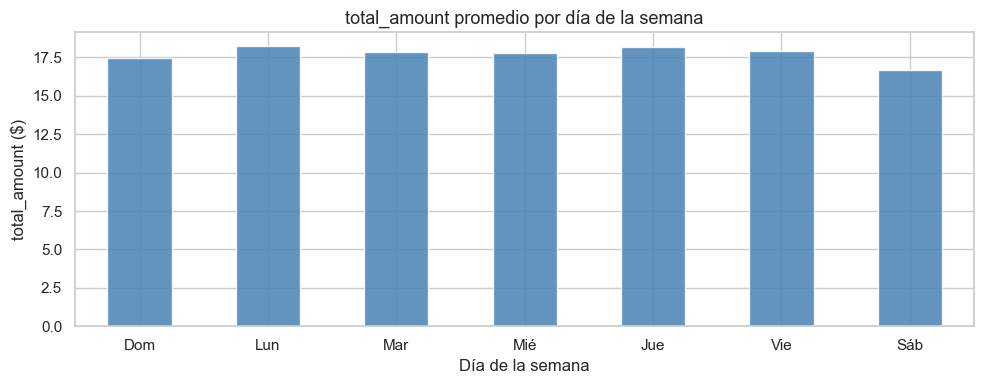

In [41]:
if 'day_of_week' in df.columns:
    day_names = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
    daily = df.groupby('day_of_week')[target].mean().rename(index=day_names)

    fig, ax = plt.subplots(figsize=(10, 4))
    daily.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title('total_amount promedio por día de la semana', fontsize=13)
    ax.set_xlabel('Día de la semana')
    ax.set_ylabel('total_amount ($)')
    ax.set_xticklabels(daily.index, rotation=0)
    plt.tight_layout()
    plt.savefig('../data/interim/01_daily_analysis.png', bbox_inches='tight', dpi=120)
    plt.show()

### 3.5 Trip distance vs total_amount

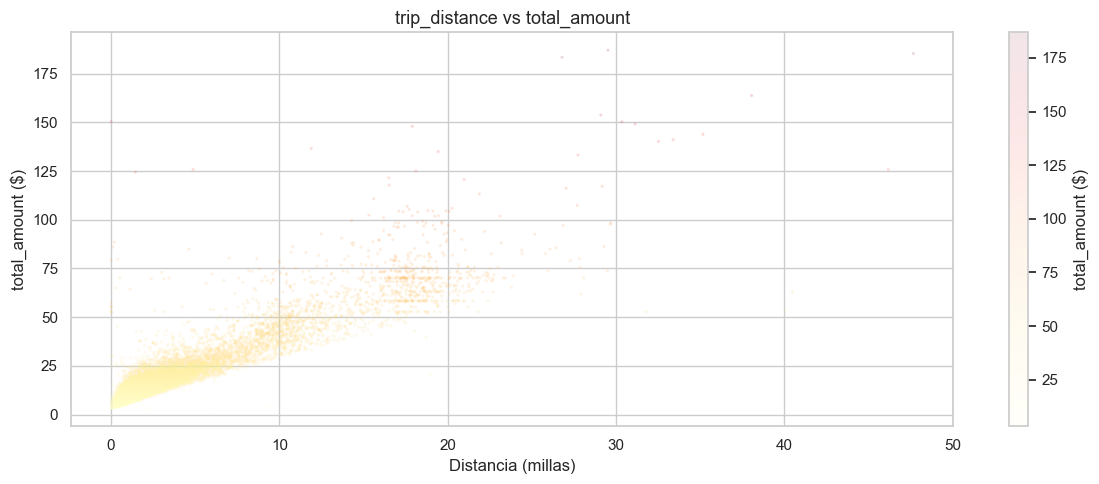

Correlación trip_distance ↔ total_amount: 0.917


In [42]:
if 'trip_distance' in df.columns:
    # Filtrar para la visualización
    df_scatter = df[
        (df['trip_distance'] > 0) & (df['trip_distance'] < 50) &
        (df[target] > 2.5) & (df[target] < 200)
    ].sample(min(20000, len(df)), random_state=RANDOM_STATE)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    scatter = ax.scatter(
        df_scatter['trip_distance'], df_scatter[target],
        alpha=0.1, s=2, c=df_scatter[target], cmap='YlOrRd'
    )
    plt.colorbar(scatter, ax=ax, label='total_amount ($)')
    ax.set_title('trip_distance vs total_amount', fontsize=13)
    ax.set_xlabel('Distancia (millas)')
    ax.set_ylabel('total_amount ($)')
    plt.tight_layout()
    plt.savefig('../data/interim/01_distance_vs_amount.png', bbox_inches='tight', dpi=120)
    plt.show()
    
    corr = df_scatter[['trip_distance', target]].corr().iloc[0, 1]
    print(f'Correlación trip_distance ↔ total_amount: {corr:.3f}')

**Observación**: Trip distance presenta una fuerte correlación con total amount (presenciable en el coeficiente y la gráfica). Lastimosamente agregarlo en el modelo representaría data leakage.

### 3.6 Análisis de variables categóricas

In [43]:
cat_cols = ['pu_borough', 'do_borough', 'payment_type_desc', 'rate_code_desc', 'vendor_name', 'source_service']
cat_cols_present = [c for c in cat_cols if c in df.columns]

for col in cat_cols_present:
    print(f'\n{col}: {df[col].nunique()} valores únicos')
    print(df[col].value_counts().head(10).to_string())


pu_borough: 8 valores únicos
pu_borough
Manhattan        6651120
Queens            650629
Brooklyn          334301
Unknown            95864
Bronx              48889
NaN                 6643
EWR                  592
Staten Island        477

do_borough: 8 valores únicos
do_borough
Manhattan        6492552
Queens            552160
Brooklyn          522466
Bronx              96302
Unknown            88173
NaN                20563
EWR                14180
Staten Island       2119

payment_type_desc: 6 valores únicos
payment_type_desc
Flex Fare trip    5192276
Cash              2466838
Other               73373
No charge           36171
Dispute             19821
Unknown                36

rate_code_desc: 7 valores únicos
rate_code_desc
Standard rate            7471107
JFK                       173909
Unknown                    77309
Negotiated fare            45530
Newark                     15161
Nassau or Westchester       5432
Group ride                    67

vendor_name: 4 valores úni

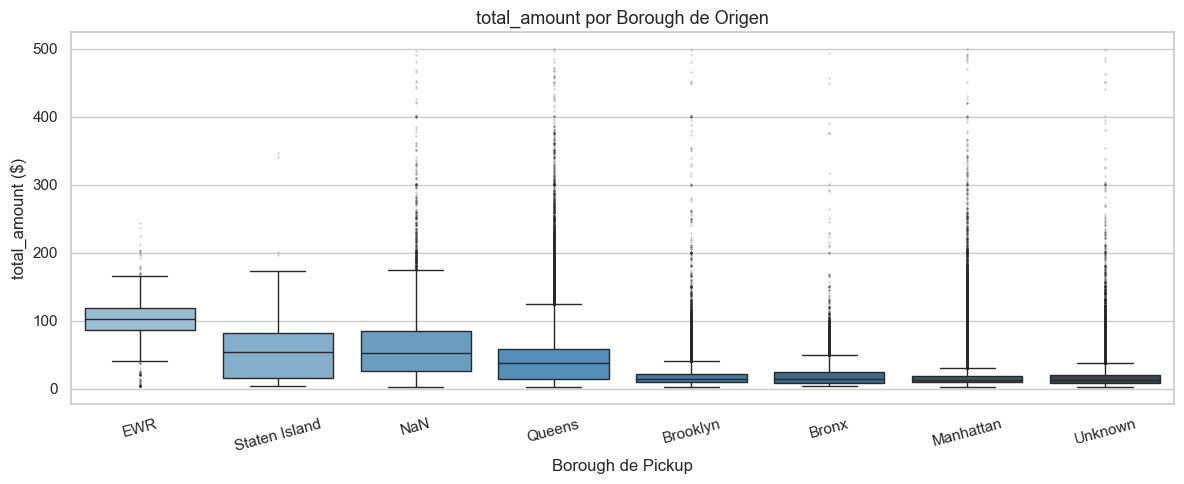

In [51]:
# Boxplots de total_amount por borough de origen
if 'pu_borough' in df.columns:
    df_box = df[(df[target] > 2.5) & (df[target] < 500) & df['pu_borough'].notna()]
    order = df_box.groupby('pu_borough')[target].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=df_box, x='pu_borough', y=target, order=order,
        palette='Blues_d', flierprops=dict(marker='.', markersize=1, alpha=0.3), ax=ax
    )
    ax.set_title('total_amount por Borough de Origen', fontsize=13)
    ax.set_xlabel('Borough de Pickup')
    ax.set_ylabel('total_amount ($)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../data/interim/01_borough_boxplot.png', bbox_inches='tight', dpi=120)
    plt.show()

**Observación**: Si bien en muchas zonas muchos datos figuran como outliers, se puede observar que estos no se encuentran solitarios; presentan elevada densidad. Esto significa que estos valores muy probablemente sean clientes con registro de viajes muy extensos antes que errores de registro. Se establecerá consecuentemente un franja de outliers aceptables en los 500$. Más allá de esta se considera que los datos son errores de digitación.

---
## 4. Heatmap de Correlaciones (features seguras)

Solo con variables sin leakage para tener la imagen limpia que guiará el feature engineering.

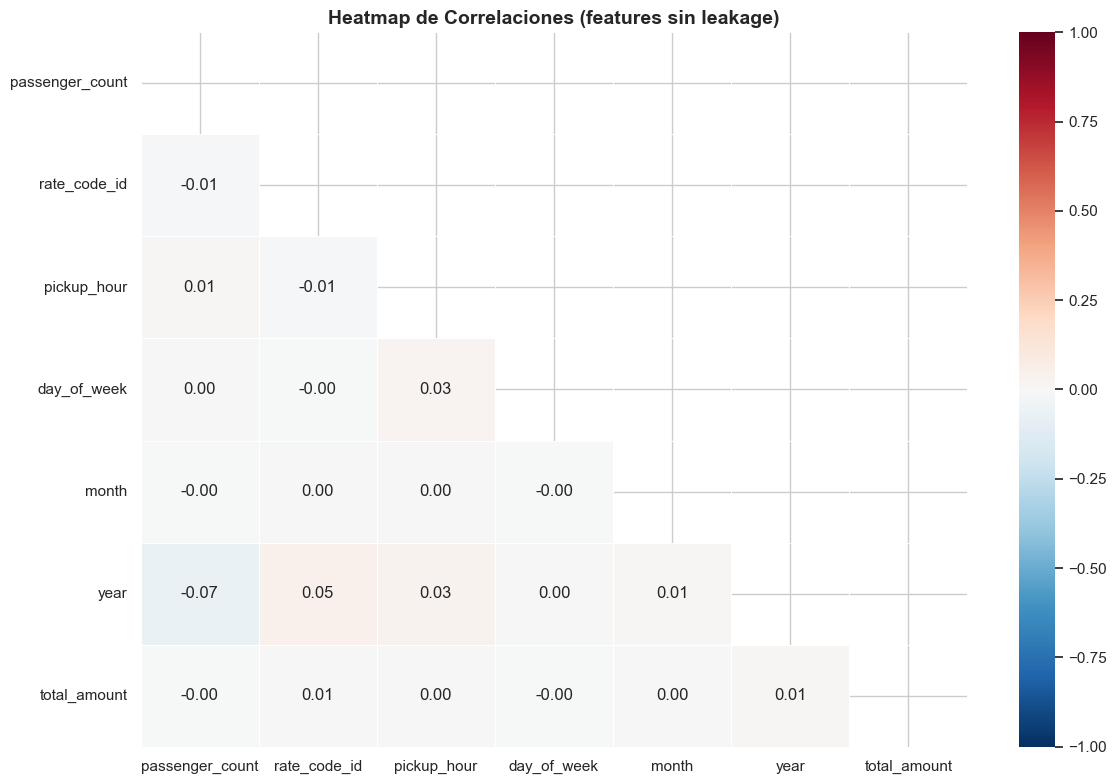

In [50]:
numeric_safe = [c for c in safe_present if c in numeric_cols] + [target]
numeric_safe = [c for c in numeric_safe if c in df.columns]

corr_safe = df[numeric_safe].corr()

mask = np.triu(np.ones_like(corr_safe, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_safe, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Heatmap de Correlaciones (features sin leakage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/01_correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

**Observación**: Ninguna de las variables numéricas observadas presenta correlación lineal entre sí, incluyendo con total amount. Se puede afirmar de esta forma que las features no presentan redundancia, pero también que ninguna de ellas presenta una correlación lineal con el target, algo negativo para modelos lineales simples.

---
## 5. Análisis de Outliers por Regla de Negocio

Más allá del IQR matemático, aplicamos lógica del dominio NYC Taxi.

In [46]:
print('=== REGLAS LÓGICAS DE NEGOCIO ===')

rules = {
    'total_amount <= 0': (df['total_amount'] <= 0).sum(),
    'total_amount > 500': (df['total_amount'] > 500).sum(),
    'trip_distance <= 0': (df['trip_distance'] <= 0).sum() if 'trip_distance' in df.columns else 'N/A',
    'trip_distance > 200': (df['trip_distance'] > 200).sum() if 'trip_distance' in df.columns else 'N/A',
    'passenger_count <= 0': (df['passenger_count'] <= 0).sum() if 'passenger_count' in df.columns else 'N/A',
    'passenger_count > 6': (df['passenger_count'] > 6).sum() if 'passenger_count' in df.columns else 'N/A',
    'PICKUP_HOUR is null': df['pickup_hour'].isnull().sum() if 'pickup_hour' in df.columns else 'N/A',
}

for rule, count in rules.items():
    pct = f'({count/len(df)*100:.3f}%)' if isinstance(count, (int, np.integer)) else ''
    print(f'  {rule:<35}: {str(count):>8} {pct}')

print(f'\nTotal de filas en la muestra: {len(df):,}')

=== REGLAS LÓGICAS DE NEGOCIO ===
  total_amount <= 0                  :    16352 (0.210%)
  total_amount > 500                 :       48 (0.001%)
  trip_distance <= 0                 :    70192 (0.901%)
  trip_distance > 200                :       98 (0.001%)
  passenger_count <= 0               :    52339 (0.672%)
  passenger_count > 6                :       90 (0.001%)
  PICKUP_HOUR is null                :        0 (0.000%)

Total de filas en la muestra: 7,788,515


---
## 6. Distribución Temporal (años en el dataset)

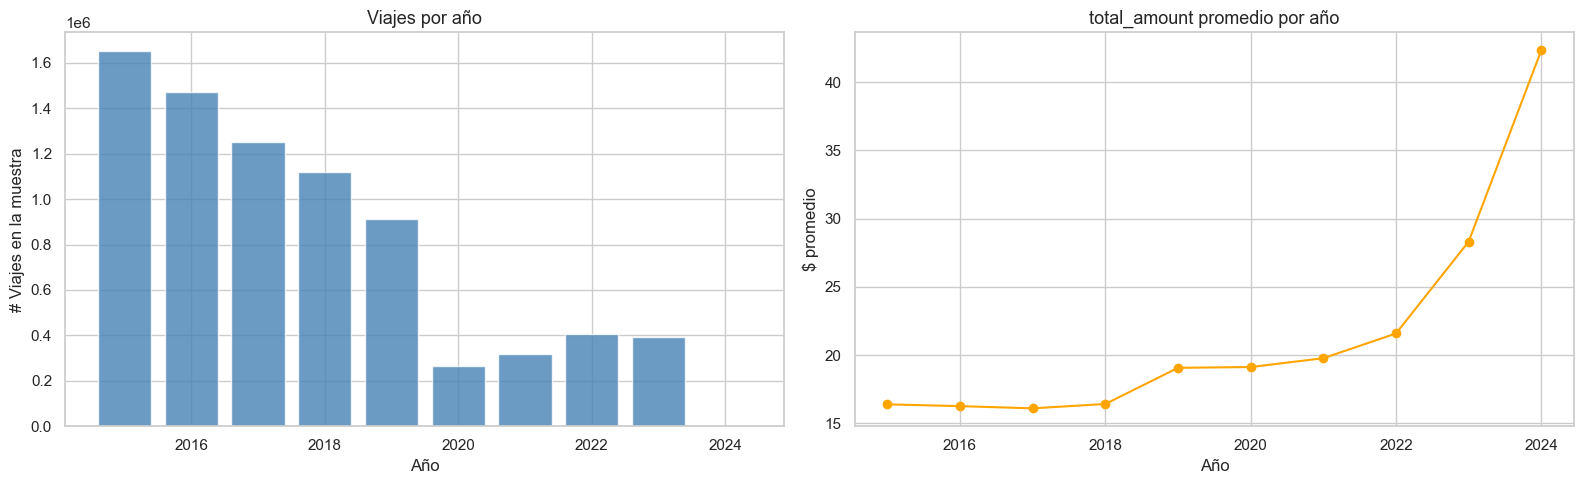

In [47]:
if 'year' in df.columns:
    yearly = df.groupby('year').agg(
        count=('total_amount', 'count'),
        avg_amount=('total_amount', 'mean')
    ).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].bar(yearly['year'], yearly['count'], color='steelblue', alpha=0.8)
    axes[0].set_title('Viajes por año', fontsize=13)
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('# Viajes en la muestra')
    
    axes[1].plot(yearly['year'], yearly['avg_amount'], marker='o', color='orange')
    axes[1].set_title('total_amount promedio por año', fontsize=13)
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('$ promedio')
    
    plt.tight_layout()
    plt.savefig('../data/interim/01_yearly_trends.png', bbox_inches='tight', dpi=120)
    plt.show()

# 7. Resumen de Hallazgos y Plan de Acción

## 1. TARGET (total_amount)
- Distribución **right-skewed** (cola hacia valores altos)
- Asimetría positiva extrema detectada
- Valores negativos/cero presentes → error de registro → **FILTRAR**
- Los modelos de boosting manejan skewness nativamente sin transformación
- Transformación `log1p` es útil para modelos lineales que requieren normalización
- **Observación**: Muchos datos figuran como outliers en zonas específicas, pero presentan elevada densidad. Probablemente representen clientes con viajes extensos (no errores de registro). La franja de outliers aceptables se establece en $500.

## 2. DATA LEAKAGE DETECTADO
- `fare_amount`, `tip_amount`, `tolls_amount`, `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee` → **ELIMINAR**
- `tip_pct` (derivada de tip_amount) → **ELIMINAR**
- `dropoff_datetime`, `trip_duration_min`, `avg_speed_mph` → **ELIMINAR**
- `run_id`, `ingested_at_utc` → no predictivos → **ELIMINAR**
- **Observación**: Las variables con mayor correlación con el target presentan en su mayoría data leakage, por lo que su poder predictivo no puede ser utilizado en producción.

## 3. OUTLIERS A FILTRAR
- `trip_distance` ≤ 0 o > 200 millas → imposibles
- `passenger_count` ≤ 0 o > 6 → fuera del rango de una taxi
- Umbral de negocio: **$2.50 < total_amount < $500**

## 4. VARIABLES MÁS PREDICTIVAS (sin leakage)
- `pickup_hour` (patrones tarifarios; viajes 4-5am y 4pm tienen media/mediana superiores)
- `day_of_week` (patrones tarifarios)
- `pu_borough`, `do_borough` (zonas geográficas)
- `rate_code_desc` (diferencia tarifas JFK, Newark, etc.)
- **Observación**: Trip distance presenta correlación directa con precio, pero incluirlo sería data leakage.

## 5. ANÁLISIS DE VARIABLES

### Temporales
- **Hora del día**: Impacto considerable en el total del viaje
  - Viajes entre 4-5am y 4pm presentan promedio/mediana superior
  - Bajo volumen en 4-5am requiere estratificación o `sample_weight` en entrenamiento

### Categóricas
- Múltiples variables categóricas con cardinalidad moderada
- Requieren One Hot Encoding para modelos que no soportan categóricas nativamente

### Correlación de features seguras
- **Ninguna variable numérica presenta correlación lineal significativa** (entre sí ni con target)
- Las features no presentan redundancia (positivo)
- **Negativo para modelos lineales simples** (requiere feature engineering no lineal)
- Los boostings son más apropiados para este escenario

### Manejo de nulos
- `congestion_surcharge` y `airport_fee`: cantidades masivas de nulos → ELIMINAR
- `passenger_count` y `rate_code_id`: cantidades moderadas de nulos → ELIMINAR
- Escala: magnitud similar entre variables → poco probable que sea necesario escalar

## 6. ACCIONES PARA EL NOTEBOOK 02
- ✅ Eliminar columnas de leakage
- ✅ Filtrar outliers de negocio
- ✅ Imputar/manejar nulos en `passenger_count`, `rate_code_id`
- ✅ Agrupar zonas de baja frecuencia en 'Other'
- ✅ Aplicar estratificación temporal en splits (no aleatorio)
- ✅ Considerar feature engineering no lineal para capturar patrones complejos

---

✅ **Configuración de EDA exportada** a `data/interim/eda_config.json`  
→ Este archivo guía el notebook 02 de limpieza.